In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.datasets import make_regression, make_classification
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

AnxietyDF = pd.read_csv("/content/AnxietyData (1).csv")
AnxietyDF.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7387 entries, 0 to 7386
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                7387 non-null   int64  
 1   Gender                             7387 non-null   object 
 2   Occupation                         7387 non-null   object 
 3   Sleep Hours                        7387 non-null   float64
 4   Physical Activity (hrs/week)       7387 non-null   float64
 5   Caffeine Intake (mg/day)           7387 non-null   int64  
 6   Alcohol Consumption (drinks/week)  7387 non-null   int64  
 7   Smoking                            7387 non-null   object 
 8   Family History of Anxiety          7387 non-null   object 
 9   Stress Level (1-10)                7387 non-null   int64  
 10  Heart Rate (bpm)                   7387 non-null   int64  
 11  Breathing Rate (breaths/min)       7387 non-null   int64

In [2]:
non_num = [
    "Gender","Occupation","Smoking",
    "Family History of Anxiety","Dizziness",
    "Medication","Recent Major Life Event",
    "Anxiety Category"
]

encoder=LabelEncoder()
for col in non_num:
    if col in AnxietyDF.columns:
        AnxietyDF[col]=encoder.fit_transform(AnxietyDF[col])

print(AnxietyDF.head())

   Age  Gender  Occupation  Sleep Hours  Physical Activity (hrs/week)  \
0   29       0           0          6.0                           2.7   
1   64       1           9          5.0                           3.7   
2   20       0          10          5.8                           2.8   
3   49       0           9          8.2                           2.3   
4   53       1           9          6.4                           6.5   

   Caffeine Intake (mg/day)  Alcohol Consumption (drinks/week)  Smoking  \
0                       181                                 10        1   
1                       117                                  4        0   
2                       360                                  6        1   
3                       247                                  4        1   
4                       235                                  2        0   

   Family History of Anxiety  Stress Level (1-10)  Heart Rate (bpm)  \
0                          0           

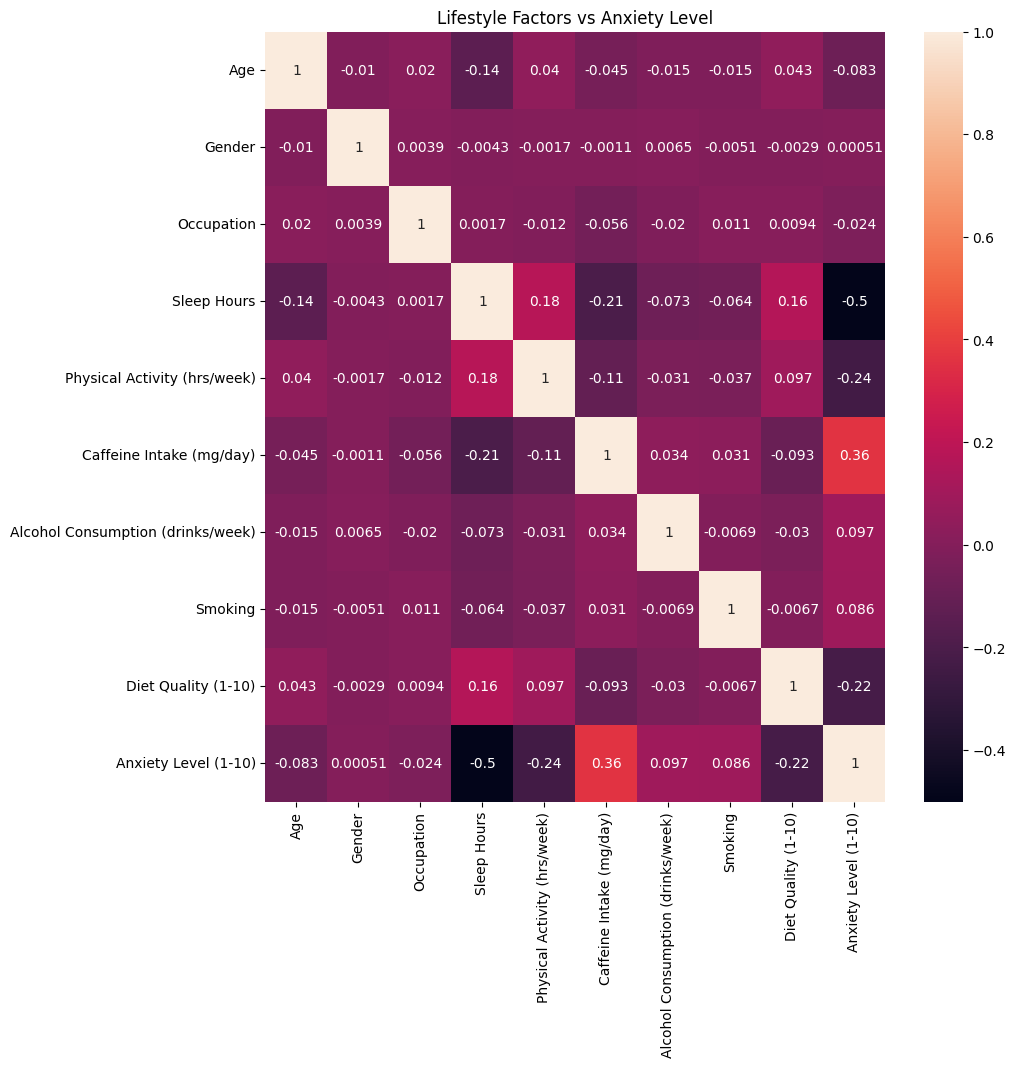

Sleep Hours                         -0.500673
Physical Activity (hrs/week)        -0.237442
Diet Quality (1-10)                 -0.224997
Age                                 -0.083356
Occupation                          -0.023733
Gender                               0.000511
Smoking                              0.086211
Alcohol Consumption (drinks/week)    0.096564
Caffeine Intake (mg/day)             0.355734
Anxiety Level (1-10)                 1.000000
Name: Anxiety Level (1-10), dtype: float64


In [3]:
AnxietyDF_Lifestyle = AnxietyDF[
[
"Age","Gender","Occupation","Sleep Hours",
"Physical Activity (hrs/week)",
"Caffeine Intake (mg/day)",
"Alcohol Consumption (drinks/week)",
"Smoking",
"Diet Quality (1-10)",
"Anxiety Level (1-10)"
]]

plt.figure(figsize=(10,10))
sns.heatmap(AnxietyDF_Lifestyle.corr(),annot=True)
plt.title("Lifestyle Factors vs Anxiety Level")
plt.show()

print(AnxietyDF_Lifestyle.corr()["Anxiety Level (1-10)"].sort_values())


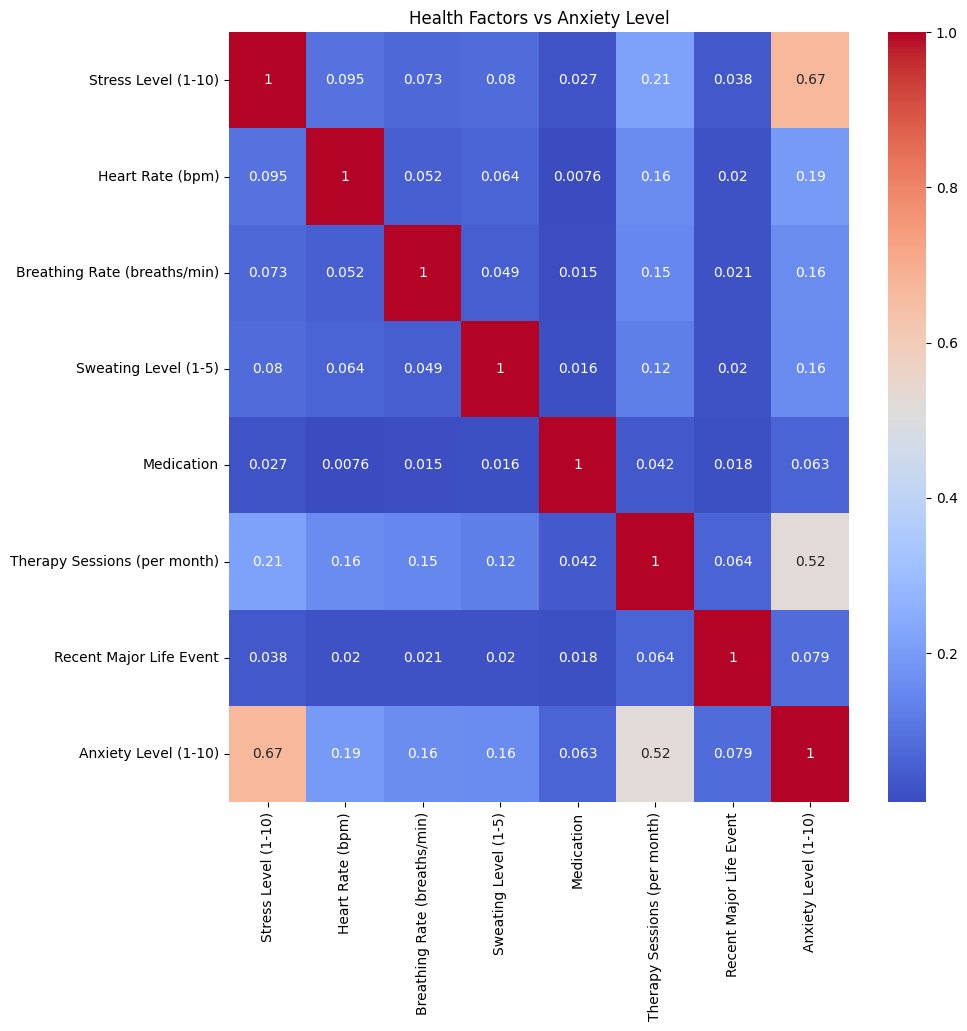

Anxiety Level (1-10)            1.000000
Stress Level (1-10)             0.669200
Therapy Sessions (per month)    0.521963
Heart Rate (bpm)                0.194448
Breathing Rate (breaths/min)    0.159528
Sweating Level (1-5)            0.156088
Recent Major Life Event         0.079364
Medication                      0.062703
Name: Anxiety Level (1-10), dtype: float64


In [4]:
AnxietyDF_Health = AnxietyDF[
[
"Stress Level (1-10)",
"Heart Rate (bpm)",
"Breathing Rate (breaths/min)",
"Sweating Level (1-5)",
"Medication",
"Therapy Sessions (per month)",
"Recent Major Life Event",
"Anxiety Level (1-10)"
]]

plt.figure(figsize=(10,10))
sns.heatmap(AnxietyDF_Health.corr(),annot=True,cmap="coolwarm")
plt.title("Health Factors vs Anxiety Level")
plt.show()

print(AnxietyDF_Health.corr()["Anxiety Level (1-10)"].sort_values(ascending=False))


(7387, 8)
(7387, 1)
Coefficient: [[-0.01 -0.57 -0.09  0.    0.01  0.4   0.01 -0.06]]
Intercept: [4.85]
[[4.9 ]
 [2.5 ]
 [3.13]
 ...
 [3.82]
 [3.17]
 [3.81]]
The mean square error is 1.55
The R2 score is 0.68


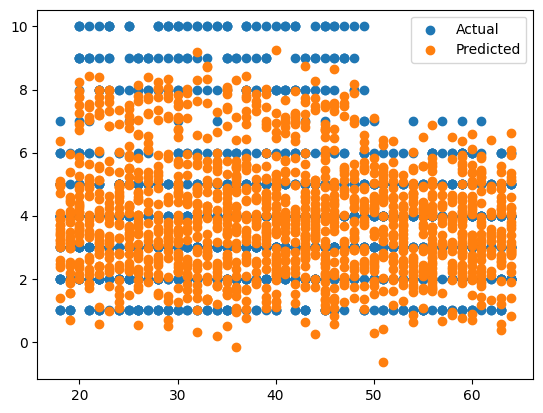

In [5]:
scaler=preprocessing.MinMaxScaler()
AnxietyDF["Age_minmax"]=scaler.fit_transform(AnxietyDF[["Age"]])

X=AnxietyDF[[
"Age","Sleep Hours","Physical Activity (hrs/week)",
"Caffeine Intake (mg/day)",
"Alcohol Consumption (drinks/week)",
"Stress Level (1-10)",
"Heart Rate (bpm)",
"Diet Quality (1-10)"
]]

y=AnxietyDF[["Anxiety Level (1-10)"]]

print(X.shape)
print(y.shape)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=21)

regressor=LinearRegression()
regressor.fit(X_train,y_train)

print("Coefficient:",np.round(regressor.coef_,2))
print("Intercept:",np.round(regressor.intercept_,2))

y_pred=regressor.predict(X_test)

print(np.round(y_pred,2))
print("The mean square error is",round(mean_squared_error(y_test,y_pred),2))
print("The R2 score is",round(r2_score(y_test,y_pred),2))

plt.figure()
plt.scatter(X_test["Age"],y_test,label="Actual")
plt.scatter(X_test["Age"],y_pred,label="Predicted")
plt.legend()
plt.show()


Predictions:
 [3.95 3.08 3.13 ... 3.26 3.36 3.48]
The mean square error is 2.34
The R2 score is 0.51


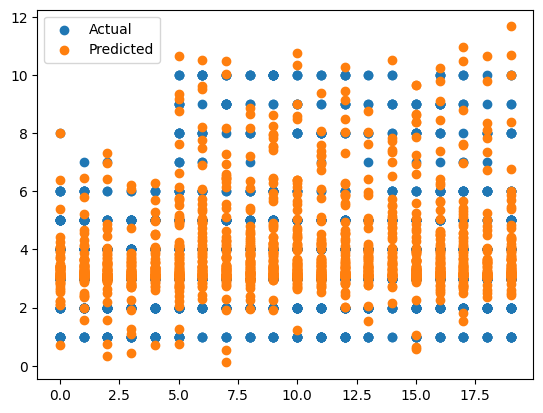

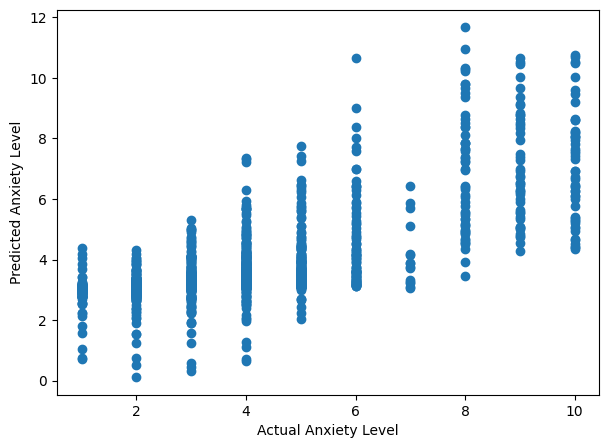

In [6]:
regressor=SVR(kernel="poly",degree=4)
regressor.fit(X_train,y_train.values.ravel())
y_pred=regressor.predict(X_test)

print("Predictions:\n",np.round(y_pred,2))
print("The mean square error is",round(mean_squared_error(y_test,y_pred),2))
print("The R2 score is",round(r2_score(y_test,y_pred),2))

plt.figure()
plt.scatter(X_test.iloc[:,4],y_test,label="Actual")
plt.scatter(X_test.iloc[:,4],y_pred,label="Predicted")
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Anxiety Level")
plt.ylabel("Predicted Anxiety Level")
plt.show()


The MSE is: 12749.26
The R^2 is: 0.49


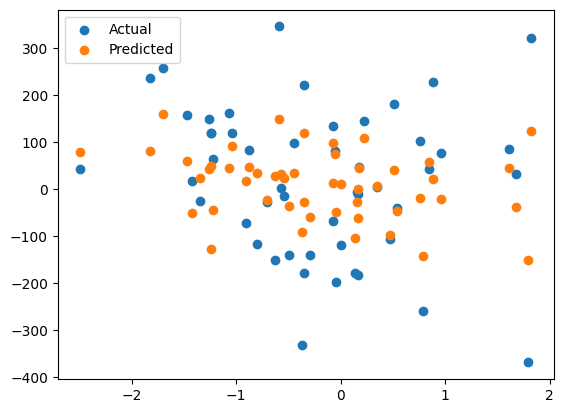

In [7]:
X,y=make_regression(n_samples=200,random_state=7)
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=7)

regr=MLPRegressor(hidden_layer_sizes=(32,8),max_iter=1500,random_state=7)
regr.fit(X_train,y_train)
y_pred=regr.predict(X_test)

print("The MSE is:",round(mean_squared_error(y_test,y_pred),2))
print("The R^2 is:",round(r2_score(y_test,y_pred),2))

plt.figure()
plt.scatter(X_test[:,1],y_test,label="Actual")
plt.scatter(X_test[:,1],y_pred,label="Predicted")
plt.legend()
plt.show()


In [8]:
features=[
"Age","Sleep Hours","Physical Activity (hrs/week)",
"Caffeine Intake (mg/day)",
"Stress Level (1-10)",
"Heart Rate (bpm)",
"Diet Quality (1-10)"
]

if "Anxiety Category" in AnxietyDF.columns:
    X=AnxietyDF[features].values
    y=AnxietyDF["Anxiety Category"].values

    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=11)

    clf=DecisionTreeClassifier(max_depth=3,random_state=11)
    clf.fit(X_train,y_train)
    print("Decision Tree Accuracy:",round(clf.score(X_test,y_test),2))

    clf_knn=KNeighborsClassifier(n_neighbors=5)
    clf_knn.fit(X_train,y_train)
    print("KNN Accuracy:",round(clf_knn.score(X_test,y_test),2))
else:
    print("Column 'Anxiety Category' not found. Classification skipped.")


Decision Tree Accuracy: 0.75
KNN Accuracy: 0.6


In [10]:
X,y=make_classification(n_samples=100,random_state=1)
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=1)

idk=MLPClassifier(hidden_layer_sizes=(32,16,8),activation="logistic",max_iter=1000,random_state=12)
idk.fit(X_train,y_train)
y_predict=idk.predict(X_test)

print("Accuracy score is",accuracy_score(y_test,y_predict))


Accuracy score is 0.92
